# Module 5 — Strategy Classification

**Research Question**: What recognizable game-theoretic strategies emerge from LLM play?

**Method**: Classify each game's 30-round action sequence by correlation with canonical strategies (ALLD, ALLC, TFT, Grim Trigger, WSLS, Random).

**Outputs**: Figure 5a (strategy distribution), Figure 5b (strategy × model × noise), Figure 5c (intended vs actual strategy)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ast
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
NOISE_LABELS = {0.0: '0%', 0.05: '5%', 0.2: '20%'}
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}

STRATEGY_COLORS = {
    'Always Defect': '#d62728',
    'Always Cooperate': '#2ca02c',
    'Tit-for-Tat': '#1f77b4',
    'Grim Trigger': '#9467bd',
    'Win-Stay-Lose-Shift': '#ff7f0e',
    'Random': '#8c564b',
    'Unclassified': '#7f7f7f'
}
FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)

# Parse strategies
df['a1_strats'] = df['agent1_strategies'].apply(ast.literal_eval)
df['a2_strats'] = df['agent2_strategies'].apply(ast.literal_eval)
df['a1_intended'] = df['agent1_intended_strategies'].apply(ast.literal_eval)

# Convert to binary: 1=Cooperate, 0=Defect
def to_binary(strats):
    return [1 if s == 'OptionB' else 0 for s in strats]

df['a1_bin'] = df['a1_strats'].apply(to_binary)
df['a2_bin'] = df['a2_strats'].apply(to_binary)
df['a1_intended_bin'] = df['a1_intended'].apply(to_binary)

print(f'Loaded {len(df)} games.')

Loaded 2160 games.


In [3]:
def generate_canonical_strategy(opp_actions, n_rounds=30):
    """Generate canonical strategy sequences given opponent's actions."""
    strategies = {}
    
    # Always Defect
    strategies['Always Defect'] = [0] * n_rounds
    
    # Always Cooperate
    strategies['Always Cooperate'] = [1] * n_rounds
    
    # Tit-for-Tat: cooperate first, then copy opponent's last action
    tft = [1]  # start with cooperation
    for t in range(1, n_rounds):
        tft.append(opp_actions[t - 1])
    strategies['Tit-for-Tat'] = tft
    
    # Grim Trigger: cooperate until opponent defects, then always defect
    grim = []
    triggered = False
    for t in range(n_rounds):
        if triggered:
            grim.append(0)
        else:
            grim.append(1)
            if t > 0 and opp_actions[t - 1] == 0:
                triggered = True
    strategies['Grim Trigger'] = grim
    
    # Win-Stay-Lose-Shift (Pavlov)
    # Cooperate if both chose same action last round, defect otherwise
    wsls = [1]  # start with cooperation
    for t in range(1, n_rounds):
        # "Win" = mutual cooperate (both 1) or I defect & they cooperate (me=0, them=1 → best payoff)
        # Actually: Win if my payoff was good (cooperate-cooperate or defect-cooperate)
        # Standard WSLS: repeat action if outcome was "good" (CC or DC), switch if "bad" (CD or DD)
        my_prev = wsls[t - 1] if t > 0 else 1
        opp_prev = opp_actions[t - 1]
        if (my_prev == 1 and opp_prev == 1) or (my_prev == 0 and opp_prev == 1):
            wsls.append(my_prev)  # stay
        else:
            wsls.append(1 - my_prev)  # shift
    strategies['Win-Stay-Lose-Shift'] = wsls
    
    return strategies

def classify_strategy(agent_actions, opp_actions, threshold=0.7):
    """Classify an agent's action sequence by correlation with canonical strategies."""
    canonical = generate_canonical_strategy(opp_actions, len(agent_actions))
    
    best_strategy = 'Unclassified'
    best_corr = -1
    correlations = {}
    
    for name, ref_actions in canonical.items():
        agent_arr = np.array(agent_actions, dtype=float)
        ref_arr = np.array(ref_actions, dtype=float)
        
        # Handle constant sequences
        if np.std(agent_arr) == 0 and np.std(ref_arr) == 0:
            corr = 1.0 if np.mean(agent_arr) == np.mean(ref_arr) else -1.0
        elif np.std(agent_arr) == 0 or np.std(ref_arr) == 0:
            # Fraction agreement
            corr = np.mean(agent_arr == ref_arr)
        else:
            corr = np.corrcoef(agent_arr, ref_arr)[0, 1]
        
        correlations[name] = corr
        if corr > best_corr:
            best_corr = corr
            best_strategy = name
    
    # Check for random: low correlation with ALL strategies
    if best_corr < threshold:
        abs_corrs = [abs(v) for v in correlations.values()]
        if max(abs_corrs) < threshold:
            # Check if it behaves randomly (close to 50% coop)
            coop_rate = np.mean(agent_actions)
            if 0.3 < coop_rate < 0.7:
                best_strategy = 'Random'
            else:
                best_strategy = 'Unclassified'
    
    return best_strategy, best_corr, correlations

print('Strategy classification functions defined.')

Strategy classification functions defined.


In [4]:
# ── Classify all games ──
results = []
for idx, row in df.iterrows():
    strat, corr, corrs = classify_strategy(row['a1_bin'], row['a2_bin'])
    strat_int, corr_int, corrs_int = classify_strategy(row['a1_intended_bin'], row['a2_bin'])
    results.append({
        'strategy': strat, 'strategy_corr': corr,
        'intended_strategy': strat_int, 'intended_strategy_corr': corr_int,
    })

res_df = pd.DataFrame(results)
df = pd.concat([df.reset_index(drop=True), res_df], axis=1)

print('Strategy distribution (actual):')
print(df['strategy'].value_counts())
print('\nStrategy distribution (intended):')
print(df['intended_strategy'].value_counts())

Strategy distribution (actual):
strategy
Always Defect       1333
Always Cooperate     629
Random               114
Tit-for-Tat           63
Grim Trigger          21
Name: count, dtype: int64

Strategy distribution (intended):
intended_strategy
Always Defect       1368
Always Cooperate     661
Tit-for-Tat           69
Random                39
Grim Trigger          23
Name: count, dtype: int64


## 5.1 Figure 5a — Overall Strategy Distribution

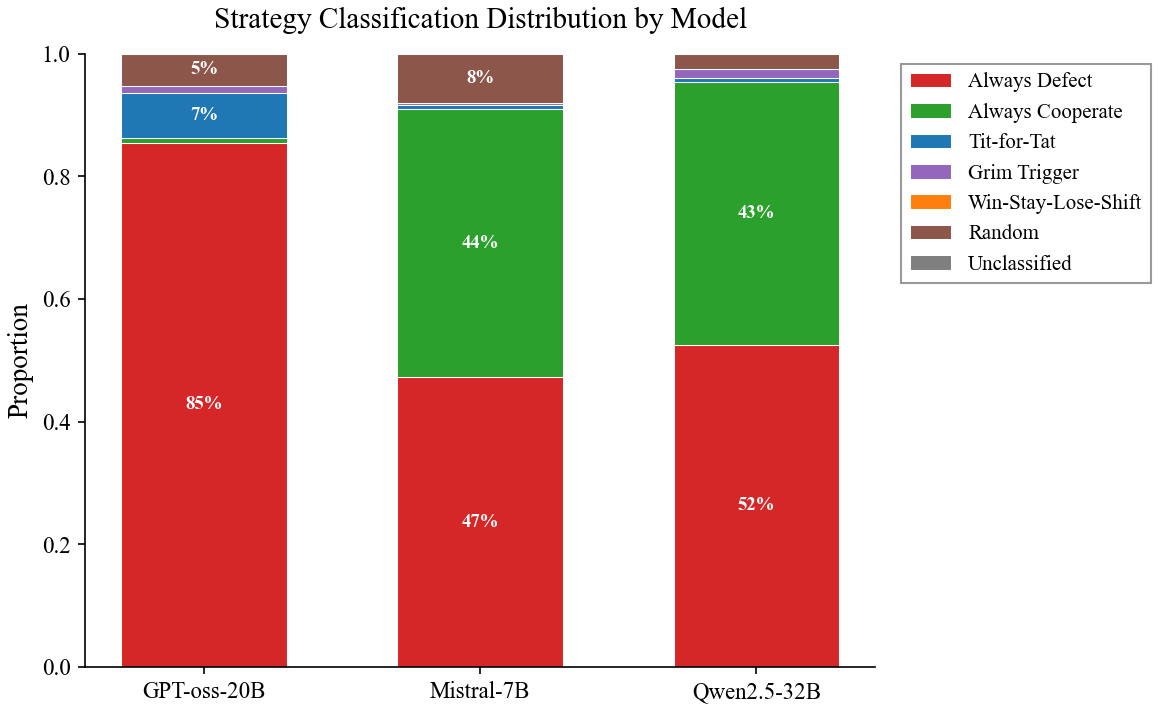

Saved: fig5a_strategy_distribution.pdf/png


In [5]:
# ── Figure 5a: Strategy distribution stacked bar per model ──
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
strat_order = ['Always Defect', 'Always Cooperate', 'Tit-for-Tat',
               'Grim Trigger', 'Win-Stay-Lose-Shift', 'Random', 'Unclassified']

fig, ax = plt.subplots(figsize=(8, 5))

# Compute proportions
strat_props = df.groupby(['model', 'strategy']).size().unstack(fill_value=0)
strat_props = strat_props.div(strat_props.sum(axis=1), axis=0).reindex(models_order)

# Ensure all strategy columns exist
for s in strat_order:
    if s not in strat_props.columns:
        strat_props[s] = 0
strat_props = strat_props[strat_order]

# Plot
bottom = np.zeros(len(models_order))
x = np.arange(len(models_order))

for strat in strat_order:
    vals = strat_props[strat].values
    bars = ax.bar(x, vals, bottom=bottom, label=strat,
                  color=STRATEGY_COLORS[strat], edgecolor='white', linewidth=0.5, width=0.6)
    
    # Label segments > 5%
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(i, b + v/2, f'{v:.0%}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(models_order)
ax.set_ylabel('Proportion')
ax.set_title('Strategy Classification Distribution by Model', fontsize=14, pad=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
          fancybox=False, edgecolor='gray')
ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig5a_strategy_distribution.pdf')
fig.savefig(f'{FIGURE_DIR}fig5a_strategy_distribution.png')
plt.show()
print('Saved: fig5a_strategy_distribution.pdf/png')

## 5.2 Figure 5b — Strategy Distribution by Model × Noise

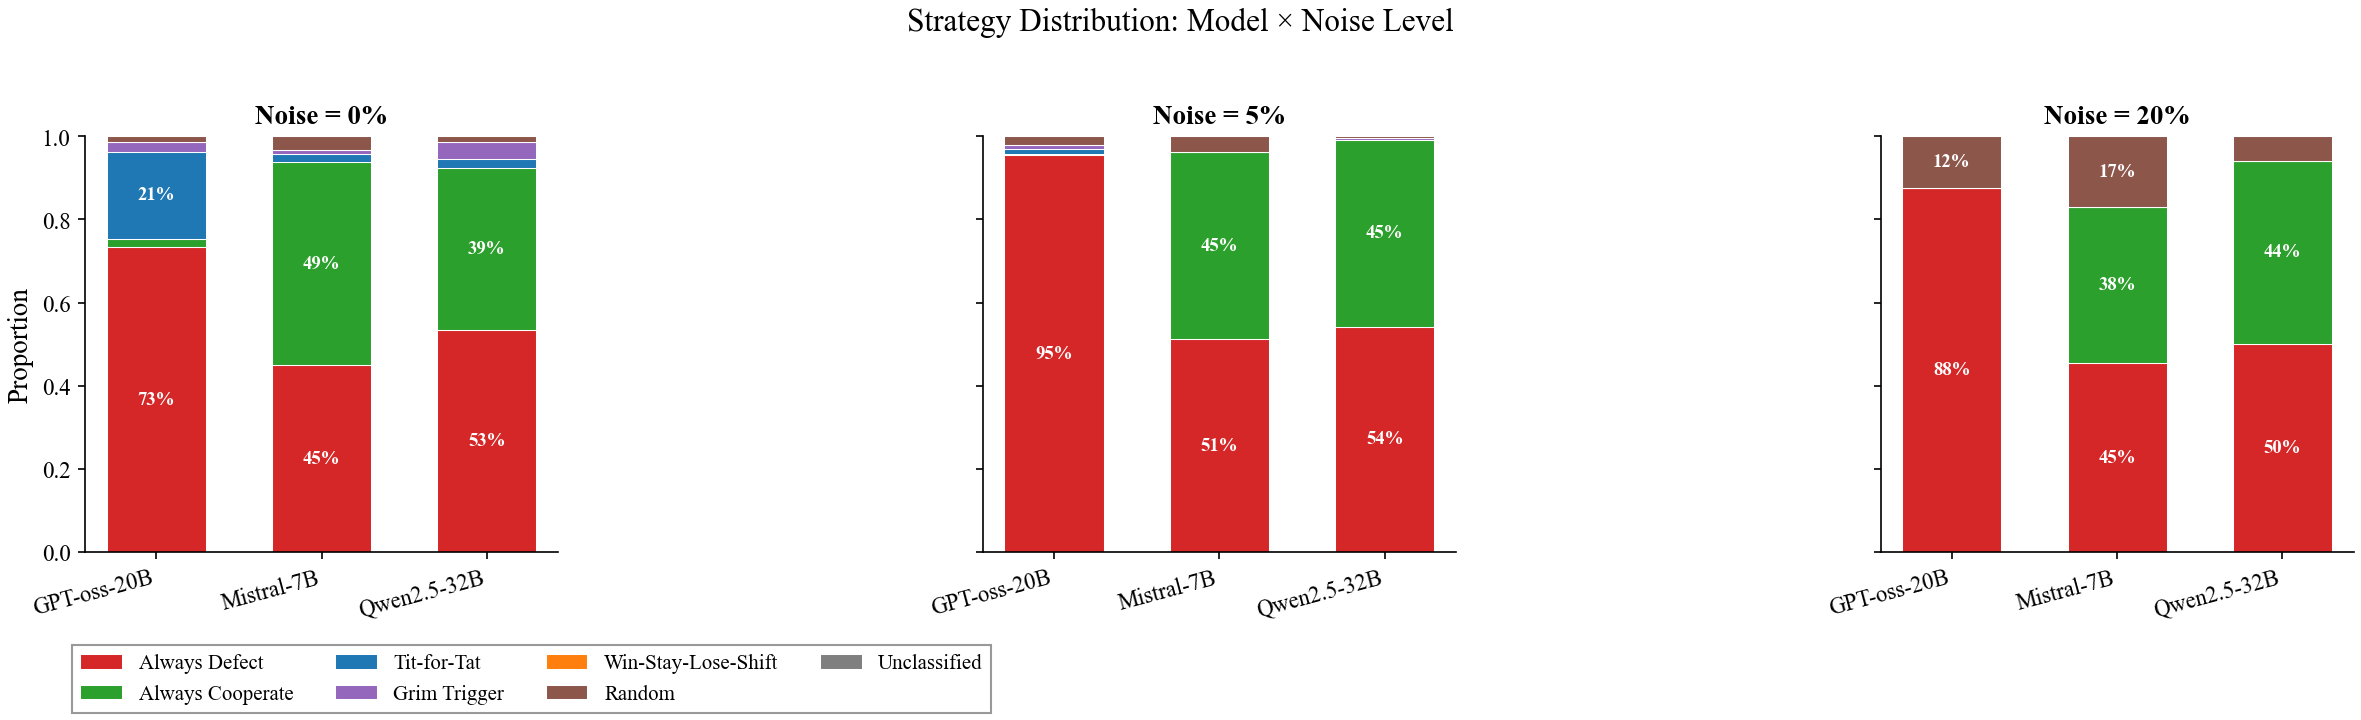

Saved: fig5b_strategy_by_noise.pdf/png


In [6]:
# ── Figure 5b: Strategy distribution faceted by noise ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
noise_levels = [0.0, 0.05, 0.2]

for ax_idx, noise in enumerate(noise_levels):
    ax = axes[ax_idx]
    sub = df[df['agent1_noise_rate'] == noise]
    
    strat_props = sub.groupby(['model', 'strategy']).size().unstack(fill_value=0)
    strat_props = strat_props.div(strat_props.sum(axis=1), axis=0).reindex(models_order)
    for s in strat_order:
        if s not in strat_props.columns:
            strat_props[s] = 0
    strat_props = strat_props[strat_order]
    
    bottom = np.zeros(len(models_order))
    x = np.arange(len(models_order))
    
    for strat in strat_order:
        vals = strat_props[strat].values
        ax.bar(x, vals, bottom=bottom, label=strat if ax_idx == 0 else '',
               color=STRATEGY_COLORS[strat], edgecolor='white', linewidth=0.5, width=0.6)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.08:
                ax.text(i, b + v/2, f'{v:.0%}', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        bottom += vals
    
    ax.set_xticks(x)
    ax.set_xticklabels(models_order, rotation=15, ha='right')
    ax.set_title(f'Noise = {NOISE_LABELS[noise]}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1)

axes[0].set_ylabel('Proportion')
axes[0].legend(bbox_to_anchor=(-0.05, -0.2), loc='upper left', ncol=4,
               frameon=True, fancybox=False, edgecolor='gray')
fig.suptitle('Strategy Distribution: Model × Noise Level', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig5b_strategy_by_noise.pdf')
fig.savefig(f'{FIGURE_DIR}fig5b_strategy_by_noise.png')
plt.show()
print('Saved: fig5b_strategy_by_noise.pdf/png')

## 5.3 Intended vs Actual Strategy (Noise Corruption)

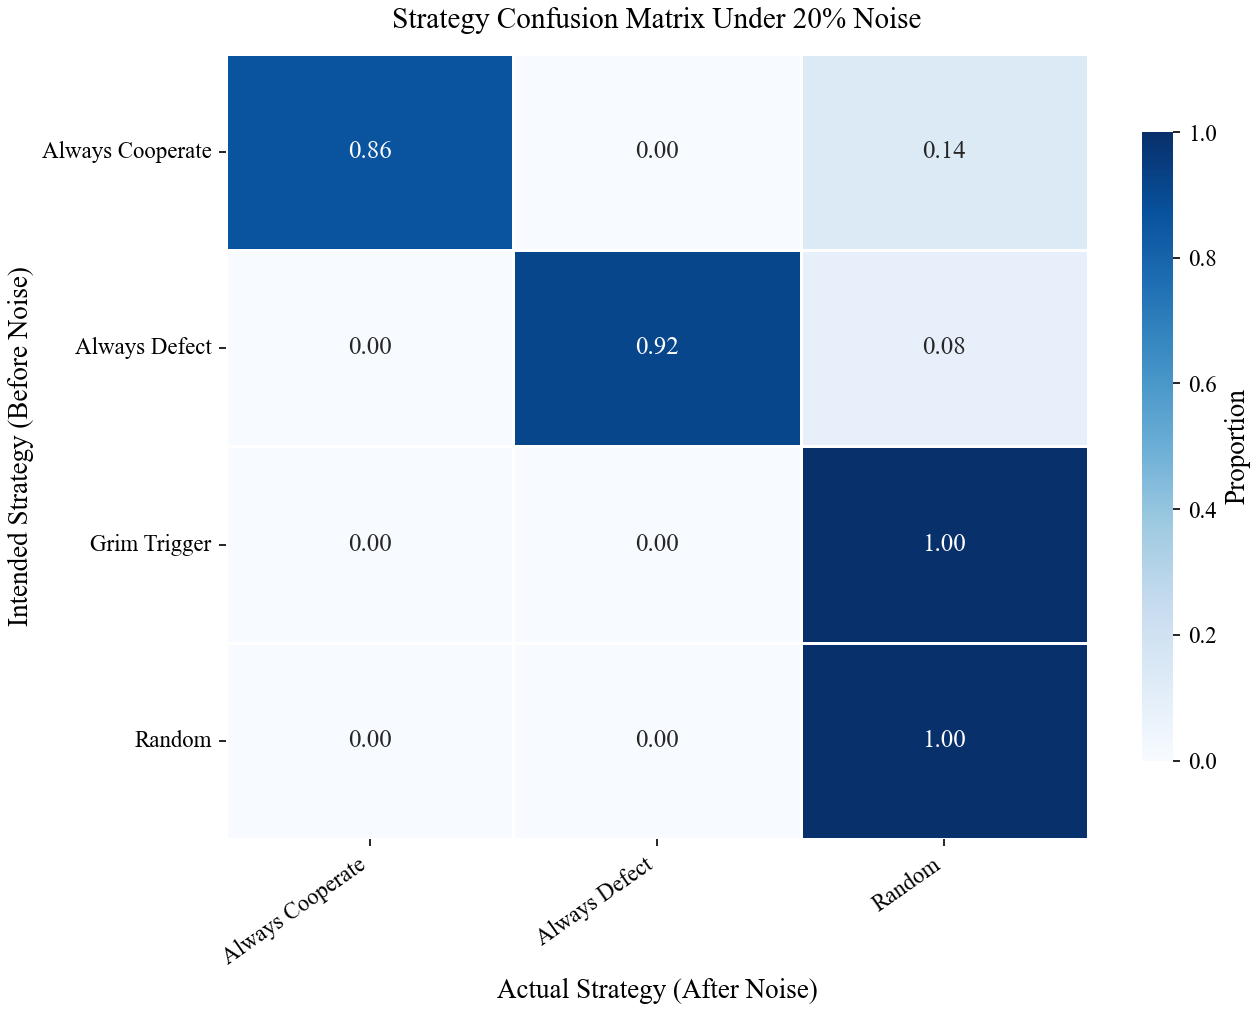

Saved: fig5c_strategy_confusion.pdf/png

Strategy retention rate under 20% noise: 90.0%


In [7]:
# ── Figure 5c: Confusion matrix — Intended vs Actual strategy under 20% noise ──
noisy = df[df['agent1_noise_rate'] == 0.2]

# Build confusion matrix
conf = pd.crosstab(noisy['intended_strategy'], noisy['strategy'],
                    margins=True, margins_name='Total')

# Remove Total for heatmap, keep for display
conf_plot = conf.drop('Total', axis=0).drop('Total', axis=1)
# Normalize by row (intended)
conf_norm = conf_plot.div(conf_plot.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Proportion', 'shrink': 0.8},
            ax=ax)
ax.set_xlabel('Actual Strategy (After Noise)', fontsize=13)
ax.set_ylabel('Intended Strategy (Before Noise)', fontsize=13)
ax.set_title('Strategy Confusion Matrix Under 20% Noise', fontsize=14, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig5c_strategy_confusion.pdf')
fig.savefig(f'{FIGURE_DIR}fig5c_strategy_confusion.png')
plt.show()
print('Saved: fig5c_strategy_confusion.pdf/png')

# Same-strategy retention rate
retained = (noisy['strategy'] == noisy['intended_strategy']).mean()
print(f'\nStrategy retention rate under 20% noise: {retained:.1%}')